# 4 · Modelo Cox Proportional Hazards (interpretable)
## WiDS Datathon 2026 — Data Wizards

El RSF gana en C-index, pero el Cox aporta lo que el bosque no: **interpretabilidad**
(Hazard Ratios con significancia) y buena **calibración**. Lo entrenamos con las 11
features seleccionadas por VIF y verificamos que sus probabilidades son coherentes.

Métricas: **C-index** (orden de riesgo) y **Brier Score / IBS** con IPCW (calibración).

In [1]:
import sys
from pathlib import Path

_SRC = next((p for p in ["src", "../src"] if (Path(p) / "wids_common.py").exists()), None)
if _SRC and _SRC not in sys.path:
    sys.path.insert(0, _SRC)

import warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from lifelines import CoxPHFitter
from sksurv.util import Surv
from sksurv.metrics import brier_score, integrated_brier_score, concordance_index_censored

from wids_common import (
    load_data, setup_style, feature_universe, safe_times,
    COX_FEATURES, HORIZONS, HORIZON_COLS,
)

PALETTE, C0, C1, C2, C3 = setup_style()
FIG_DIR = Path("figures"); FIG_DIR.mkdir(exist_ok=True)
REPORT_DIR = Path("reports"); REPORT_DIR.mkdir(exist_ok=True)

PENALIZER = 0.05   # L2 para estabilizar con n=221
df_train, df_test = load_data()
ALL_FEATURES = feature_universe(df_train, df_test)
strat = df_train["event"].astype(int)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
print(f"Features Cox (VIF <= 5): {len(COX_FEATURES)}")


def fit_cox(df_tr, feats):
    """Ajusta un CoxPHFitter sobre features escaladas; devuelve (modelo, scaler)."""
    s = StandardScaler()
    X = pd.DataFrame(s.fit_transform(df_tr[feats]), columns=feats)
    X["time_to_hit_hours"] = df_tr["time_to_hit_hours"].values
    X["event"] = df_tr["event"].values
    m = CoxPHFitter(penalizer=PENALIZER)
    m.fit(X, duration_col="time_to_hit_hours", event_col="event")
    return m, s

Features Cox (VIF <= 5): 11


## 4.1 Escenarios: por qué 11 features y no 33

Sin podar la colinealidad, el Cox es inestable: la varianza del C-index entre folds se
dispara. Comparamos el set completo (33) contra el seleccionado (11).

In [2]:
def cox_cv_cindex(feats):
    sc = []
    for tr, va in cv.split(df_train, strat):
        m, s = fit_cox(df_train.iloc[tr], feats)
        Xva = pd.DataFrame(s.transform(df_train.iloc[va][feats]), columns=feats)
        risk = m.predict_partial_hazard(Xva).values
        y_va = Surv.from_dataframe("event", "time_to_hit_hours", df_train.iloc[va])
        sc.append(concordance_index_censored(y_va["event"], y_va["time_to_hit_hours"], risk)[0])
    return np.mean(sc), np.std(sc)


c33 = cox_cv_cindex(ALL_FEATURES)
c11 = cox_cv_cindex(COX_FEATURES)
print(f"Cox con 33 features : C = {c33[0]:.4f} ± {c33[1]:.4f}   (varianza enorme)")
print(f"Cox con 11 features : C = {c11[0]:.4f} ± {c11[1]:.4f}   (estable)")
print(f"\nLa selección reduce la varianza ~{c33[1] / c11[1]:.0f}x sin perder discriminación.")

Cox con 33 features : C = 0.8655 ± 0.0986   (varianza enorme)
Cox con 11 features : C = 0.9219 ± 0.0204   (estable)

La selección reduce la varianza ~5x sin perder discriminación.


## 4.2 Validación cruzada — C-index, Brier Score e IBS

Evaluamos el modelo final (11 features) por fold con las tres métricas.

In [3]:
records = []
for fold, (tr, va) in enumerate(cv.split(df_train, strat), 1):
    df_tr, df_va = df_train.iloc[tr], df_train.iloc[va]
    y_tr = Surv.from_dataframe("event", "time_to_hit_hours", df_tr)
    y_va = Surv.from_dataframe("event", "time_to_hit_hours", df_va)
    tf = safe_times(y_tr, y_va)

    m, s = fit_cox(df_tr, COX_FEATURES)
    Xva = pd.DataFrame(s.transform(df_va[COX_FEATURES]), columns=COX_FEATURES)
    risk = m.predict_partial_hazard(Xva).values
    c = concordance_index_censored(y_va["event"], y_va["time_to_hit_hours"], risk)[0]
    sf = m.predict_survival_function(Xva, times=tf).T.values
    ibs = integrated_brier_score(y_tr, y_va, sf, tf)
    row = {"fold": fold, "C_index": c, "IBS": ibs}
    for t, b in zip(tf, brier_score(y_tr, y_va, sf, tf)[1]):
        row[f"BS_{t}h"] = b
    records.append(row)

cvdf = pd.DataFrame(records)
print("Resumen CV (media ± std):")
for col in [c for c in cvdf.columns if c != "fold"]:
    print(f"  {col:<10} {cvdf[col].mean():.4f} ± {cvdf[col].std():.4f}")
print("\nReferencia: el modelo nulo (predecir 0.5) tiene IBS = 0.25 -> el Cox es ~4x mejor.")

Resumen CV (media ± std):
  C_index    0.9219 ± 0.0228
  IBS        0.0654 ± 0.0259
  BS_12h     0.0744 ± 0.0202
  BS_24h     0.0664 ± 0.0268
  BS_48h     0.0593 ± 0.0310

Referencia: el modelo nulo (predecir 0.5) tiene IBS = 0.25 -> el Cox es ~4x mejor.


## 4.3 Modelo final e interpretación

`print_summary` da el coeficiente, el Hazard Ratio (`exp(coef)`), el p-value y el IC 95 %
de cada feature. HR < 1 = protector (más tiempo sin amenaza); HR > 1 = factor de riesgo.

In [4]:
cph, scaler = fit_cox(df_train, COX_FEATURES)
cph.print_summary(decimals=3)
print(f"\nConcordance index (train): {cph.concordance_index_:.4f}")

sig = cph.summary[cph.summary["p"] < 0.05]
print(f"\nFeatures significativas (p < 0.05): {len(sig)}")
print(sig[["coef", "exp(coef)", "p"]].round(3).to_string())

<lifelines.CoxPHFitter: fitted with 221 total observations, 152 right-censored observations>
             duration col = 'time_to_hit_hours'
                event col = 'event'
                penalizer = 0.05
                 l1 ratio = 0.0
      baseline estimation = breslow
   number of observations = 221
number of events observed = 69
   partial log-likelihood = -264.414
         time fit was run = 2026-06-12 18:30:10 UTC

---
                     coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                            
dist_min_ci_0_5h   -0.386     0.680     0.267          -0.909           0.138               0.403               1.147
log_dist_min       -1.526     0.217     0.191          -1.901          -1.152               0.149               0.316
dt_first_last_0_5h  0.078     1.081     0.174          -0.263           0.419               0.769               1.520
alignment_abs       0.345     1.412     0.158           0.036           0.655               1.036               1.925
aligned_speed      -0.062     0.940     0.105          -0.267           0.143               0.765               1.154
spread_bearing_cos -0.042     0.958     0.109          -0.256           0.171               0.774               1.186
log1p_growth        0.048     1.049     0.144          -0.235           0.331               0.791               1.392
dist_fit_r2_0_5h    0.073     1.076     0.117          -0.157           0.303               0.855               1.354
spread_bearing_sin  0.079     1.082     0.103          -0.123           0.282               0.884               1.325
area_first_ha      -0.118     0.889     0.212          -0.533           0.298               0.587               1.347
dist_std_ci_0_5h    0.077     1.081     0.090          -0.099           0.254               0.906               1.289

                    cmp to      z       p  -log2(p)
covariate                                          
dist_min_ci_0_5h     0.000 -1.445   0.149     2.751
log_dist_min         0.000 -7.994 <0.0005    49.441
dt_first_last_0_5h   0.000  0.448   0.654     0.612
alignment_abs        0.000  2.187   0.029     5.121
aligned_speed        0.000 -0.592   0.554     0.852
spread_bearing_cos   0.000 -0.390   0.697     0.521
log1p_growth         0.000  0.332   0.740     0.434
dist_fit_r2_0_5h     0.000  0.622   0.534     0.905
spread_bearing_sin   0.000  0.768   0.442     1.176
area_first_ha        0.000 -0.556   0.578     0.790
dist_std_ci_0_5h     0.000  0.860   0.390     1.359
---
Concordance = 0.924
Partial AIC = 550.828
log-likelihood ratio test = 176.106 on 11 df
-log2(p) of ll-ratio test = 103.598


Concordance index (train): 0.9243

Features significativas (p < 0.05): 2
                coef  exp(coef)      p
covariate                             
log_dist_min  -1.526      0.217  0.000
alignment_abs  0.345      1.412  0.029


Solo **dos** features son significativas: `log_dist_min` (HR ≈ 0.22, fuerte protector:
más distancia → mucho más tiempo sin amenaza) y `alignment_abs` (HR ≈ 1.4, riesgo: un
fuego bien alineado hacia la zona llega antes). Coincide con el EDA.

## 4.4 Forest plot de Hazard Ratios

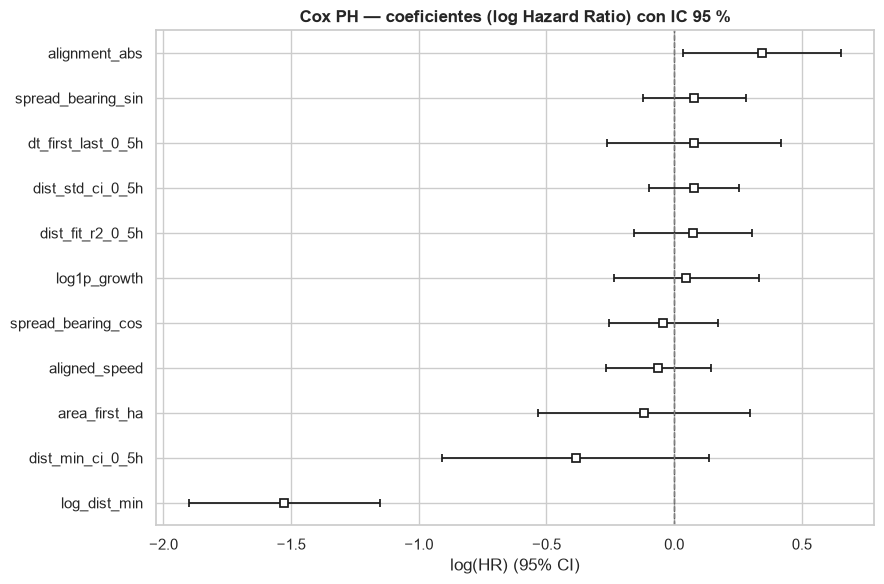

In [5]:
fig, ax = plt.subplots(figsize=(9, 6))
cph.plot(ax=ax)
ax.axvline(0, color="gray", ls="--", lw=1)
ax.set_title("Cox PH — coeficientes (log Hazard Ratio) con IC 95 %", fontweight="bold")
plt.tight_layout()
plt.savefig(FIG_DIR / "32_cox_forest_plot.png", dpi=150, bbox_inches="tight")
plt.show()

## 4.5 Predicción en test y monotonicidad

Como `prob_h = 1 - S(h)` y S(t) no crece, debe cumplirse
`prob_12h <= prob_24h <= prob_48h <= prob_72h` para cada incendio. Lo verificamos.

In [6]:
Xte = pd.DataFrame(scaler.transform(df_test[COX_FEATURES]), columns=COX_FEATURES)
sf_te = cph.predict_survival_function(Xte, times=HORIZONS)
pred = df_test[["event_id"]].copy()
for h, col in zip(HORIZONS, HORIZON_COLS):
    pred[col] = np.clip(1 - sf_te.loc[h].values, 0, 1)

P = pred[HORIZON_COLS].values
peor_caida = float(np.diff(P, axis=1).min())
violan = int((np.diff(P, axis=1) < -1e-9).any(axis=1).sum())
print(f"Monotonicidad: caída máxima = {peor_caida:+.6f} | incendios que violan = {violan}/{len(pred)}")
print(f"Estado: {'OK (todas monótonas)' if violan == 0 else 'REVISAR'}")

print("\nProbabilidad media de amenaza en test:")
for col in HORIZON_COLS:
    print(f"  {col}: {pred[col].mean():.3f}")
pred.to_csv(REPORT_DIR / "pred_test_cox.csv", index=False)
print("\nGuardado: reports/pred_test_cox.csv")

Monotonicidad: caída máxima = +0.000000 | incendios que violan = 0/95
Estado: OK (todas monótonas)

Probabilidad media de amenaza en test:
  prob_12h: 0.216
  prob_24h: 0.294
  prob_48h: 0.316
  prob_72h: 0.420

Guardado: reports/pred_test_cox.csv


## Resumen

- Cox con 11 features (VIF ≤ 5), `penalizer = 0.05`.
- **C-index CV ≈ 0.925**, **IBS ≈ 0.065** (~4x mejor que el modelo nulo).
- Solo 2 features significativas: distancia (protector) y alineación (riesgo).
- Predicciones 100 % monótonas.

El RSF gana en C-index, pero el Cox da la lectura interpretable del fenómeno. La
comparación lado a lado está en `validation.ipynb`.